# Image Field Data Demo

Use synthetic microscopy image data as initial conditions for a spatial simulation,
then visualize results with an interactive 3D Trame widget.

In [1]:
import numpy as np
from scipy.ndimage import gaussian_filter
import pyvcell.vcml as vc

## Load model and set up simulation

In [2]:
import os
from pathlib import Path

model_path = Path(os.getcwd()).parent / "models" / "Tutorial_MultiApp_PDE.vcml"
biomodel = vc.load_vcml_file(model_path)
app = biomodel.applications[0]
sim = app.simulations[0]
sim.mesh_size = (100, 100, 36)
sim.duration = 2.0
sim.output_time_step = 0.2

## Build synthetic microscopy image from geometry domain mask

In [3]:
seg = app.geometry.to_segmented_image(resolution=64)
mask = seg.get_mask("cytosol").astype(float)
image_data = gaussian_filter(mask, sigma=3) + 0.05 * np.random.randn(*mask.shape)

print(f"Image shape: {image_data.shape}, Mesh size: {sim.mesh_size}")

Image shape: (256, 256, 34), Mesh size: (100, 100, 36)


## Create field and use as initial condition

In [4]:
field = vc.Field(data_name="microscopy", data_nD=image_data)
app.get_species_mapping("Ran_cyt").init_conc = field.expression

print(f"Initial condition: {field.expression}")

Initial condition: vcField('microscopy', 'channel_1', 0.0, 'Volume')


## Simulate

The solver resamples the 64x64x64 image data to the 20x20x20 simulation mesh via trilinear interpolation.

In [5]:
result = vc.simulate(biomodel, sim.name, fields=[field])

print(f"Time points: {result.time_points}")
print(f"Channels: {[c.label for c in result.channel_data]}")

Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2026-03-29T20:03:27.134719Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2026-03-29T20:03:27.139446Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@369b79f7 and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2026-03-29T20:03:27.463309Z main WARN The Logger cbit.vcell.mapping.AbstractMathMapping was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@369b79f7 and is now requested with a null message factory (defaults to org.ap

Simulation Complete in Main() ... 


initializing mesh
numVolume=360000

CartesianMesh::computeNormalsFromNeighbors(), compute normals from neighbors
Membrane Elements -> N=16661
qhull precision error: initial simplex is not convex. Distance=-1.2e-16
559 has 0 neighbors !
qhull precision warning: 
1132 has 0 neighbors !
qhull precision warning: 
2202 has 0 neighbors !
13777 has 0 neighbors !
--------Num of points that have zero neighbors 4
--------Num Neighbors before symmetrize 99119
--------Num Neighbors after symmetrize 108070
Total volume=6062.500738
Total FluxArea =47.45975686
Total FluxAreaXM =0
Total FluxAreaXP =0
Total FluxAreaYM =32.00361766
Total FluxAreaYP =15.45613919
Total FluxAreaZM =0
Total FluxAreaZP =0
mesh initialized
preprocessing finished
**This is a little endian machine.**

read data for field 'microscopy'.
pdeCount=4, odeCount=0
No log-file found at constructed path `/Users/jimschaff/Documents/workspace/pyvcell/examples/notebooks/workspace/out_dir_qir12gq4/SimID_1289029706_0_.log`.simulation [SimID_

## Visualize results

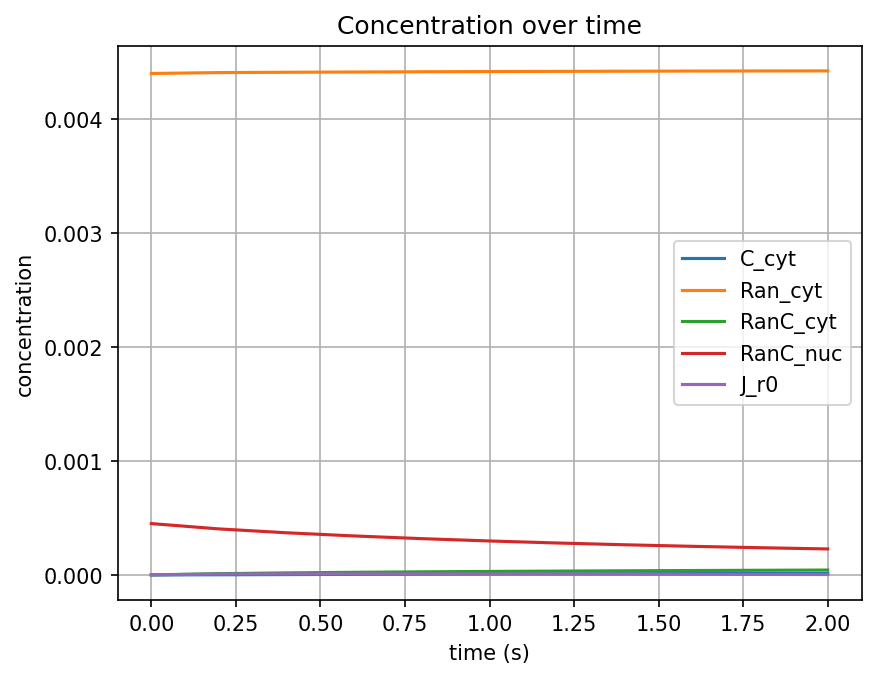

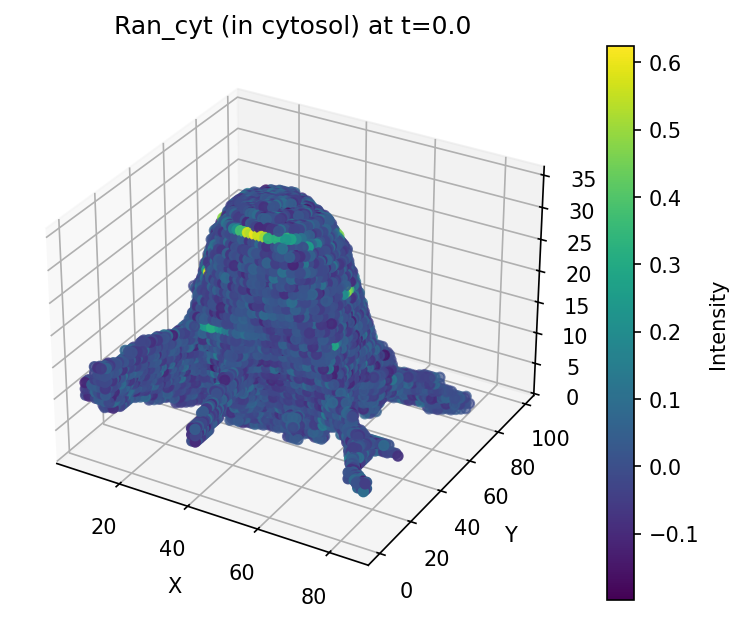

In [6]:
result.plotter.plot_concentrations()
result.plotter.plot_slice_3d(time_index=0, channel_id="Ran_cyt")

## Interactive 3D visualization with Trame

In [7]:
import pyvcell.sim_results.widget as widget

viewer = widget.App(result.vtk_data)
layout = await viewer.run()
display(layout.ipywidget)

HTML(value='<iframe id="trame_trame__template_main" src="http://localhost:8889/trame-jupyter-server/servers/tr…